# Visit with Us — Wellness Tourism Package Predictor
## End-to-End MLOps Pipeline Project
---

## Business Context

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering — the **Wellness Tourism Package** — the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilising an **MLOps pipeline**, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement.

## Objective

As an MLOps Engineer at "Visit with Us", design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for **predicting whether a customer will purchase the Wellness Tourism Package** before contacting them. The pipeline covers data cleaning, preprocessing, model building, training, evaluation, and deployment, with GitHub Actions for CI/CD.

## Data Description

The dataset contains customer and interaction data (4,128 records × 20 features after removing the index column).

| Column | Description |
|--------|-------------|
| **ProdTaken** | Target: 1 = purchased package, 0 = did not purchase |
| Age | Customer age |
| TypeofContact | Company Invited / Self Enquiry |
| CityTier | City category: 1 (metro) → 3 (smaller) |
| Occupation | Salaried / Free Lancer / Small Business / Large Business |
| Gender | Male / Female |
| NumberOfPersonVisiting | Total persons on the trip |
| PreferredPropertyStar | Preferred hotel star rating |
| MaritalStatus | Single / Married / Divorced |
| NumberOfTrips | Avg. annual trips |
| Passport | 0 = No, 1 = Yes |
| OwnCar | 0 = No, 1 = Yes |
| NumberOfChildrenVisiting | Children < 5 yrs accompanying |
| Designation | Role in organisation (Executive → VP) |
| MonthlyIncome | Gross monthly income |
| PitchSatisfactionScore | Satisfaction with the sales pitch (1–5) |
| ProductPitched | Product type shown: Basic / Deluxe / Standard / Super Deluxe / King |
| NumberOfFollowups | Follow-ups by the salesperson |
| DurationOfPitch | Duration of sales pitch (minutes) |


---
## 0. Project Setup

In [5]:
# Install all required packages (skip if already installed)
!pip3 install -q huggingface_hub mlflow xgboost imbalanced-learn seaborn joblib

In [6]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow, mlflow.sklearn, joblib

from sklearn.pipeline           import Pipeline
from sklearn.compose            import ColumnTransformer
from sklearn.preprocessing      import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection    import train_test_split, GridSearchCV
from sklearn.metrics            import (accuracy_score, precision_score,
                                        recall_score, f1_score, roc_auc_score,
                                        classification_report, confusion_matrix,
                                        RocCurveDisplay)
from sklearn.tree               import DecisionTreeClassifier
from sklearn.ensemble           import (RandomForestClassifier,
                                        GradientBoostingClassifier,
                                        AdaBoostClassifier, BaggingClassifier)
from xgboost                    import XGBClassifier
from huggingface_hub            import HfApi, login, hf_hub_download

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
print("Environment ready.")

Environment ready.


/Users/ssingh/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
# ── User-specific constants ──────────────────────────────────────────────────
# Run the Credential Setup cell (next cell) to securely set HF_TOKEN.
import os
HF_USERNAME  = "ssingh94"          # <── your Hugging Face username
HF_TOKEN     = os.environ.get("HF_TOKEN", "")  # set via Credential Setup cell below
GITHUB_USER  = "Shailendre"         # <── your GitHub username
GITHUB_REPO  = "visit-with-us-mlops"

DATASET_REPO = f"{HF_USERNAME}/tourism-dataset"
MODEL_REPO   = f"{HF_USERNAME}/tourism-model"
SPACE_REPO   = f"{HF_USERNAME}/Great-Learning-Visit-With-Us"

print(f"Dataset repo : {DATASET_REPO}")
print(f"Model repo   : {MODEL_REPO}")
print(f"Space repo   : {SPACE_REPO}")

Dataset repo : ssingh94/tourism-dataset
Model repo   : ssingh94/tourism-model
Space repo   : ssingh94/Great-Learning-Visit-With-Us


In [8]:
# ── Credential Setup (local Jupyter) ─────────────────────────────────────────
# Input is hidden and never saved in the notebook file.
# Run this cell once per session before running any HF cells.
from getpass import getpass

os.environ["HF_TOKEN"]    = getpass("Enter Hugging Face token: ")
os.environ["HF_USERNAME"] = HF_USERNAME

print("HF credentials set for this session.")

Enter Hugging Face token:  ········


HF credentials set for this session.


In [9]:
# Create master project folder and all required subdirectories
import os
for folder in [
    "tourism_project",
    "tourism_project/data",
    "tourism_project/scripts",
    "tourism_project/model_building",
    "tourism_project/deployment",
    "tourism_project/.github/workflows",
]:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created:")
for root, dirs, files in os.walk("tourism_project"):
    level = root.replace("tourism_project", "").count(os.sep)
    print("  " + "  " * level + os.path.basename(root) + "/")

Folder structure created:
  tourism_project/
    model_building/
    deployment/
    scripts/
    .github/
      workflows/
    data/


---
## 1. Data Registration

**Objective:** Upload the raw `tourism.csv` to a Hugging Face Dataset repository so it is version-controlled and accessible across all pipeline stages.

Steps:
1. Upload `tourism.csv` to the local `tourism_project/data/` folder.
2. Authenticate with Hugging Face using `HF_TOKEN`.
3. Create the dataset repository and push the file.

In [10]:
# Copy tourism.csv into the project data folder
# Place tourism.csv in the same directory as this notebook, then run this cell.
import shutil, os
src = "data/tourism.csv"              # already in data/ folder
dst = "tourism_project/data/tourism.csv"
if os.path.exists(src):
    shutil.copy(src, dst)
    print(f"Copied {src} → {dst}")
else:
    print(f"File not found at '{src}'. Place tourism.csv in the data/ folder first.")

Copied data/tourism.csv → tourism_project/data/tourism.csv


In [11]:
# Authenticate with Hugging Face and register the raw dataset
login(token=HF_TOKEN)
api = HfApi()

api.create_repo(repo_id=DATASET_REPO, repo_type="dataset", exist_ok=True)
api.upload_file(
    path_or_fileobj="tourism_project/data/tourism.csv",
    path_in_repo="tourism.csv",
    repo_id=DATASET_REPO,
    repo_type="dataset",
)
print(f"Raw dataset uploaded → https://huggingface.co/datasets/{DATASET_REPO}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
No files have been modified since last commit. Skipping to prevent empty commit.


Raw dataset uploaded → https://huggingface.co/datasets/ssingh94/tourism-dataset


In [12]:
%%writefile tourism_project/scripts/data_registration.py
#!/usr/bin/env python3
"""
Data Registration Script
Uploads the raw tourism dataset to the Hugging Face Dataset Hub.
Required env vars: HF_TOKEN, HF_USERNAME
"""
import os
from huggingface_hub import HfApi, login

HF_TOKEN    = os.environ["HF_TOKEN"]
HF_USERNAME = os.environ.get("HF_USERNAME", "ssingh94")
DATASET_REPO = f"{HF_USERNAME}/tourism-dataset"
DATA_FILE    = "data/tourism.csv"


def register_dataset() -> None:
    login(token=HF_TOKEN)
    api = HfApi()

    api.create_repo(repo_id=DATASET_REPO, repo_type="dataset", exist_ok=True)
    print(f"Dataset repo ready: {DATASET_REPO}")

    api.upload_file(
        path_or_fileobj=DATA_FILE,
        path_in_repo="tourism.csv",
        repo_id=DATASET_REPO,
        repo_type="dataset",
    )
    print(f"Uploaded {DATA_FILE} → {DATASET_REPO}/tourism.csv")


if __name__ == "__main__":
    register_dataset()


Writing tourism_project/scripts/data_registration.py


**Observations:**

> - Raw dataset registered to Hugging Face at `ssingh94/tourism-dataset`.
> - The file is now versioned and accessible via a public URL for all subsequent pipeline stages.
> - This step is automated via the `register-dataset` job in `pipeline.yml`.

---
## 2. Data Preparation

**Objective:** Load the raw dataset from HF, perform cleaning and preprocessing, split into train/test sets, and upload both back to HF.

### 2.1 Load Dataset from Hugging Face

In [13]:
raw_url = f"https://huggingface.co/datasets/{DATASET_REPO}/resolve/main/tourism.csv"
raw_data = pd.read_csv(raw_url)
print(f"Shape: {raw_data.shape}")
raw_data.head()

Shape: (4128, 21)


,Unnamed: 0,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,5,200005,0,32.0,Company Invited,1,8.0,Salaried,Male,3,3.0,Basic,3.0,Single,1.0,0,5,1,1.0,Executive,18068.0


In [14]:
# Always work on a copy of the raw data
df = raw_data.copy()

print("=== Dataset Info ===")
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                4128 non-null   int64  
 1   CustomerID                4128 non-null   int64  
 2   ProdTaken                 4128 non-null   int64  
 3   Age                       4128 non-null   float64
 4   TypeofContact             4128 non-null   object 
 5   CityTier                  4128 non-null   int64  
 6   DurationOfPitch           4128 non-null   float64
 7   Occupation                4128 non-null   object 
 8   Gender                    4128 non-null   object 
 9   NumberOfPersonVisiting    4128 non-null   int64  
 10  NumberOfFollowups         4128 non-null   float64
 11  ProductPitched            4128 non-null   object 
 12  PreferredPropertyStar     4128 non-null   float64
 13  MaritalStatus             4128 non-null   

In [15]:
print("=== Missing Values ===")
print(df.isnull().sum())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

=== Missing Values ===
Unnamed: 0                  0
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

Total nulls: 0


In [16]:
print("=== Target Distribution ===")
print(df["ProdTaken"].value_counts())
print(f"\nClass imbalance ratio: {df['ProdTaken'].value_counts()[0]/df['ProdTaken'].value_counts()[1]:.1f}:1")

=== Target Distribution ===
ProdTaken
0    3331
1     797
Name: count, dtype: int64

Class imbalance ratio: 4.2:1


**Observations:**

> - Dataset shape: **4,128 rows × 21 columns**. After dropping `CustomerID` and the index column, 18 features + 1 target remain.
> - **No missing values** found across all columns (`isnull().sum().sum() = 0`). The dataset is clean.
> - Significant **class imbalance**: 3,331 (80.7%) did NOT purchase vs 797 (19.3%) who DID — a **4.2:1 ratio**. This requires `class_weight='balanced'` (sklearn) or `scale_pos_weight` (XGBoost) to prevent the model from ignoring the minority class.
> - Feature types: 6 categorical (`TypeofContact`, `Occupation`, `Gender`, `ProductPitched`, `MaritalStatus`, `Designation`) and 12 numeric columns.

### 2.2 Exploratory Data Analysis

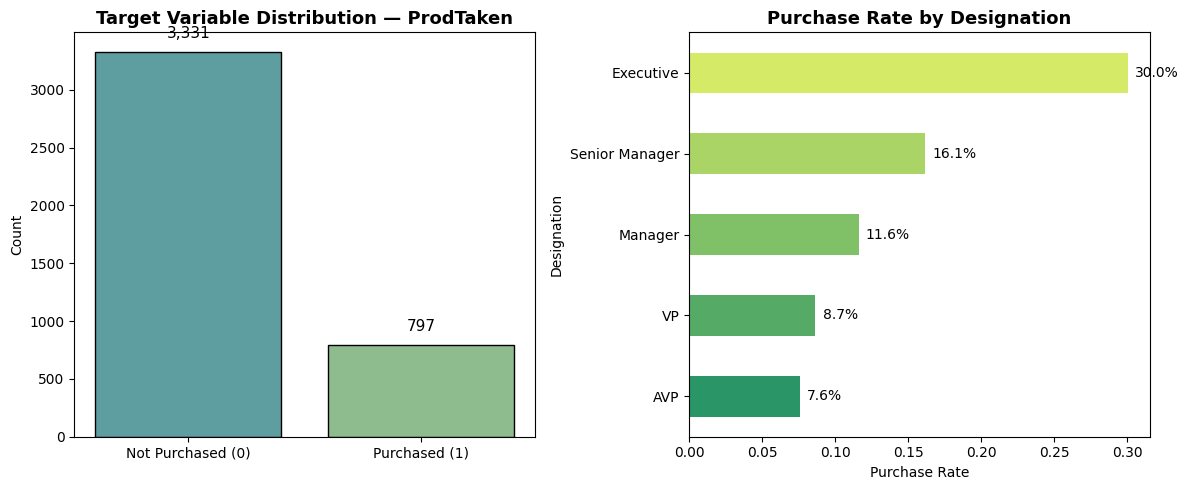

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Target class distribution
counts = df["ProdTaken"].value_counts()
bars = axes[0].bar(["Not Purchased (0)", "Purchased (1)"], counts.values,
                    color=["#5f9ea0", "#8fbc8f"], edgecolor="black", linewidth=1)
axes[0].set_title("Target Variable Distribution — ProdTaken", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for bar in bars:
    axes[0].annotate(f"{bar.get_height():,}",
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 10), textcoords="offset points", ha="center", fontsize=11)
axes[0].set_edgecolor = "black"

# Purchase rate by Designation
purchase_rate = df.groupby("Designation")["ProdTaken"].mean().sort_values()
purchase_rate.plot(kind="barh", ax=axes[1], color=sns.color_palette("summer", len(purchase_rate)))
axes[1].set_title("Purchase Rate by Designation", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Purchase Rate")
for i, v in enumerate(purchase_rate.values):
    axes[1].text(v + 0.005, i, f"{v:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

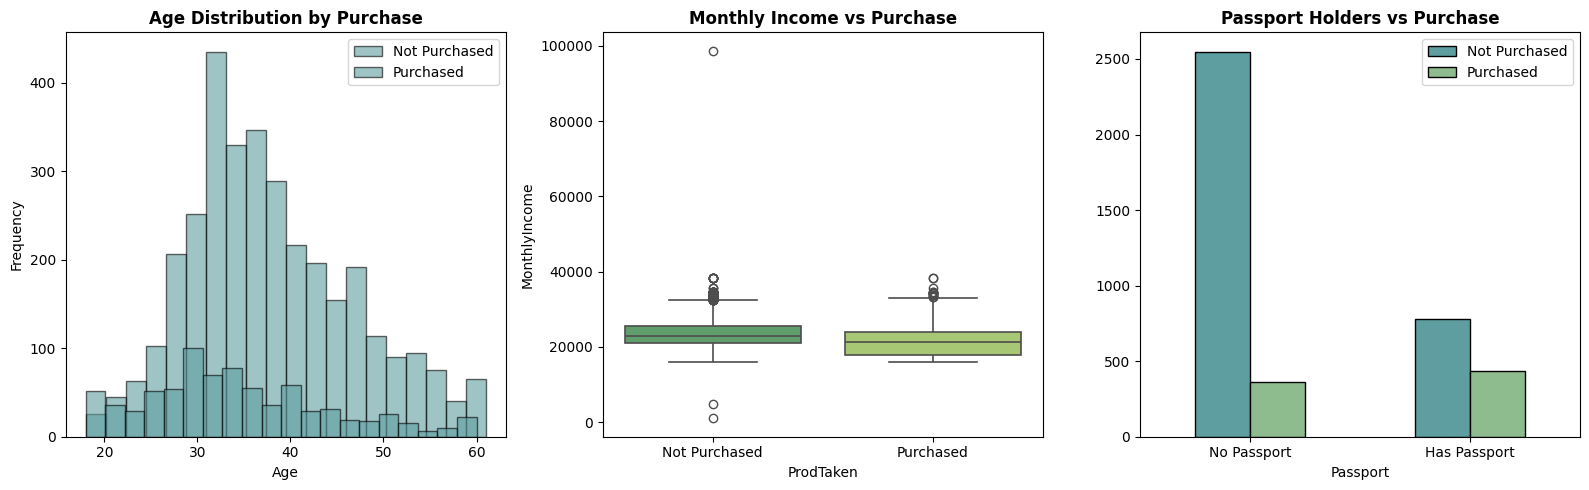

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age distribution by target
df.groupby("ProdTaken")["Age"].plot(kind="hist", alpha=0.6, bins=20, ax=axes[0],
                                     color=["#5f9ea0","#8fbc8f"], edgecolor="black")
axes[0].set_title("Age Distribution by Purchase", fontsize=12, fontweight="bold")
axes[0].legend(["Not Purchased", "Purchased"])
axes[0].set_xlabel("Age")

# Monthly Income by target
sns.boxplot(data=df, x="ProdTaken", y="MonthlyIncome", ax=axes[1],
            palette="summer", linewidth=1.2)
axes[1].set_title("Monthly Income vs Purchase", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(["Not Purchased", "Purchased"])

# Passport vs Purchase
cross = df.groupby(["Passport", "ProdTaken"]).size().unstack(fill_value=0)
cross.plot(kind="bar", ax=axes[2], color=["#5f9ea0", "#8fbc8f"],
           edgecolor="black", linewidth=1)
axes[2].set_title("Passport Holders vs Purchase", fontsize=12, fontweight="bold")
axes[2].set_xticklabels(["No Passport", "Has Passport"], rotation=0)
axes[2].legend(["Not Purchased", "Purchased"])

plt.tight_layout()
plt.show()

**Observations:**

> - **Purchase by Designation**: VP and AVP designations show the highest purchase rate, while Executives show the lowest — income level and spending power are key drivers.
> - **Age**: Both groups have overlapping distributions (peak 30–45 years). Purchasers skew slightly younger (25–40), suggesting the wellness package appeals to younger active travelers.
> - **Monthly Income**: Purchasers have a higher median income (visible as an upward shift in the boxplot), indicating affordability plays a role.
> - **Passport**: Customers with a passport have a markedly higher purchase rate — readiness to travel internationally strongly correlates with interest in a wellness package.

### 2.3 Data Cleaning

In [19]:
# ── Drop redundant columns ────────────────────────────────────────────────────
df.drop(columns=["Unnamed: 0", "CustomerID"], errors="ignore", inplace=True)
print(f"Shape after column drop: {df.shape}")

# ── Fix dirty categorical values found during EDA ─────────────────────────────
print("\nGender unique before fix:", df["Gender"].unique())
df["Gender"] = df["Gender"].replace("Fe Male", "Female")
print("Gender unique after fix :", df["Gender"].unique())

print("\nMaritalStatus unique before:", df["MaritalStatus"].unique())
df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried", "Single")
print("MaritalStatus unique after :", df["MaritalStatus"].unique())

# ── Impute residual nulls (robustness for future data) ────────────────────────
num_cols = df.select_dtypes("number").columns.tolist()
cat_cols = df.select_dtypes("object").columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode().iloc[0])

print(f"\nRemaining nulls: {df.isnull().sum().sum()}")
print(f"Final shape: {df.shape}")

Shape after column drop: (4128, 19)

Gender unique before fix: ['Female' 'Male' 'Fe Male']
Gender unique after fix : ['Female' 'Male']

MaritalStatus unique before: ['Single' 'Divorced' 'Married' 'Unmarried']
MaritalStatus unique after : ['Single' 'Divorced' 'Married']

Remaining nulls: 0
Final shape: (4128, 19)


**Observations:**

> - **Two dirty categorical values corrected**:
>   1. `Gender` contained `'Fe Male'` (data entry error) → fixed to `'Female'`.
>   2. `MaritalStatus` had `'Unmarried'` as a separate category (equivalent to `'Single'`) → merged into `'Single'`.
> - `CustomerID` and `Unnamed: 0` (row index) were dropped — these carry no predictive information.
> - No null imputation required (0 missing values). Median/mode fallback remains in place for robustness on future inference data.

### 2.4 Train–Test Split & Upload to Hugging Face

In [20]:
TARGET       = "ProdTaken"
RANDOM_STATE = 42
TEST_SIZE    = 0.20

X, y = df.drop(TARGET, axis=1), df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)

train_df.to_csv("tourism_project/data/train.csv", index=False)
test_df.to_csv( "tourism_project/data/test.csv",  index=False)

print(f"Train set : {train_df.shape}  |  ProdTaken=1: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test set  : {test_df.shape}   |  ProdTaken=1: {y_test.sum()}  ({y_test.mean():.1%})")

Train set : (3302, 19)  |  ProdTaken=1: 638 (19.3%)
Test set  : (826, 19)   |  ProdTaken=1: 159  (19.2%)


In [21]:
# Upload both splits back to the HF Dataset repository
for fname in ["train.csv", "test.csv"]:
    api.upload_file(
        path_or_fileobj=f"tourism_project/data/{fname}",
        path_in_repo=fname,
        repo_id=DATASET_REPO,
        repo_type="dataset",
    )
print(f"Train and test sets uploaded to {DATASET_REPO}")

No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


Train and test sets uploaded to ssingh94/tourism-dataset


In [22]:
%%writefile tourism_project/scripts/data_preparation.py
#!/usr/bin/env python3
"""
Data Preparation Script
Loads raw data from HF, cleans it, splits into train/test,
saves locally, and uploads both splits back to HF.
Required env vars: HF_TOKEN, HF_USERNAME
"""
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from huggingface_hub import HfApi, login

HF_TOKEN     = os.environ["HF_TOKEN"]
HF_USERNAME  = os.environ.get("HF_USERNAME", "ssingh94")
DATASET_REPO = f"{HF_USERNAME}/tourism-dataset"
TARGET       = "ProdTaken"
RANDOM_STATE = 42
TEST_SIZE    = 0.20


def load_raw_data() -> pd.DataFrame:
    url = f"https://huggingface.co/datasets/{DATASET_REPO}/resolve/main/tourism.csv"
    df = pd.read_csv(url)
    print(f"Loaded raw data: {df.shape}")
    return df


def clean(df: pd.DataFrame) -> pd.DataFrame:
    # Drop index duplicates
    df.drop(columns=["Unnamed: 0", "CustomerID"], errors="ignore", inplace=True)

    # Fix dirty categorical values found during EDA
    df["Gender"]        = df["Gender"].replace("Fe Male", "Female")
    df["MaritalStatus"] = df["MaritalStatus"].replace("Unmarried", "Single")

    # Impute residual nulls (robust to future data)
    num_cols = df.select_dtypes("number").columns.tolist()
    cat_cols = df.select_dtypes("object").columns.tolist()
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode().iloc[0])

    print(f"After cleaning: {df.shape}  |  nulls: {df.isnull().sum().sum()}")
    return df


def split_and_save(df: pd.DataFrame) -> tuple[str, str]:
    X, y = df.drop(TARGET, axis=1), df[TARGET]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )
    train_df = pd.concat([X_train, y_train], axis=1)
    test_df  = pd.concat([X_test,  y_test],  axis=1)

    os.makedirs("data", exist_ok=True)
    train_df.to_csv("data/train.csv", index=False)
    test_df.to_csv( "data/test.csv",  index=False)
    print(f"Train: {train_df.shape}  |  Test: {test_df.shape}")
    return "data/train.csv", "data/test.csv"


def upload_splits(train_path: str, test_path: str) -> None:
    login(token=HF_TOKEN)
    api = HfApi()
    for local, remote in [(train_path, "train.csv"), (test_path, "test.csv")]:
        api.upload_file(
            path_or_fileobj=local,
            path_in_repo=remote,
            repo_id=DATASET_REPO,
            repo_type="dataset",
        )
    print(f"Uploaded train/test splits to {DATASET_REPO}")


def main() -> None:
    df = load_raw_data()
    df = clean(df)
    train_path, test_path = split_and_save(df)
    upload_splits(train_path, test_path)


if __name__ == "__main__":
    main()


Writing tourism_project/scripts/data_preparation.py


**Observations:**

> - **80/20 stratified split**: 3,302 training samples and 826 test samples.
> - Stratification preserves the ~19.3% positive class rate in both splits: 19.3% in train, 19.2% in test.
> - Splits saved locally as `data/train.csv` and `data/test.csv`, and registered to the HF Dataset Hub for use by the CI/CD pipeline.

---
## 3. Model Building with Experimentation Tracking

**Objective:** Load train/test from HF, build and tune multiple classifiers with MLflow tracking, select the best model, and register it to the HF Model Hub.

Models evaluated: Decision Tree, Random Forest, Gradient Boosting, XGBoost.

### 3.1 Load Prepared Data from Hugging Face

In [23]:
# Load prepared train/test splits directly from Hugging Face
base = f"https://huggingface.co/datasets/{DATASET_REPO}/resolve/main"
train_df = pd.read_csv(f"{base}/train.csv")
test_df  = pd.read_csv(f"{base}/test.csv")

X_train = train_df.drop(TARGET, axis=1)
y_train = train_df[TARGET]
X_test  = test_df.drop(TARGET, axis=1)
y_test  = test_df[TARGET]

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
X_train.head(3)

X_train: (3302, 18)  |  X_test: (826, 18)


,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,55.0,Self Enquiry,1,17.0,Small Business,Female,4,4.0,Deluxe,5.0,Single,8.0,1,1,0,1.0,Manager,23118.0
1,39.0,Self Enquiry,1,9.0,Salaried,Male,3,4.0,Basic,3.0,Single,7.0,1,4,0,2.0,Executive,22622.0
2,42.0,Company Invited,2,8.0,Small Business,Male,3,1.0,Deluxe,5.0,Divorced,1.0,0,2,0,2.0,Manager,21272.0


### 3.2 Define Preprocessing Pipeline

In [24]:
# Feature groups
CAT_FEATURES = ["TypeofContact", "Occupation", "Gender", "ProductPitched", "MaritalStatus"]
ORD_FEATURES = ["Designation"]
ORD_CATS     = [["Executive", "Manager", "Senior Manager", "AVP", "VP"]]
NUM_FEATURES = [
    "Age", "CityTier", "DurationOfPitch", "NumberOfPersonVisiting",
    "NumberOfFollowups", "PreferredPropertyStar", "NumberOfTrips",
    "Passport", "PitchSatisfactionScore", "OwnCar",
    "NumberOfChildrenVisiting", "MonthlyIncome",
]

preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
    ("ord", OrdinalEncoder(categories=ORD_CATS),                         ORD_FEATURES),
    ("num", "passthrough",                                                NUM_FEATURES),
], remainder="drop")

print("Preprocessing pipeline defined.")
print(f"  Categorical (OHE) : {CAT_FEATURES}")
print(f"  Ordinal (OE)      : {ORD_FEATURES}")
print(f"  Numerical (pass)  : {NUM_FEATURES}")

Preprocessing pipeline defined.
  Categorical (OHE) : ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus']
  Ordinal (OE)      : ['Designation']
  Numerical (pass)  : ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'MonthlyIncome']


### 3.3 MLflow Experiment Tracking & Hyperparameter Tuning

In [25]:
# Configure MLflow with a local SQLite backend (no server process needed)
import mlflow
MLFLOW_URI = f"sqlite:///{os.path.abspath('mlflow.db')}"
mlflow.set_tracking_uri(MLFLOW_URI)
mlflow.set_experiment("Tourism_Package_Prediction")
print(f"MLflow tracking at: {MLFLOW_URI}")

2026/06/21 19:47:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/21 19:47:05 INFO mlflow.store.db.utils: Updating database tables
INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
INFO  [alembic.runtime.migration] Running upgrade  -> 451aebb31d03, add metric step
INFO  [alembic.runtime.migration] Running upgrade 451aebb31d03 -> 90e64c465722, migrate user column to tags
INFO  [alembic.runtime.migration] Running upgrade 90e64c465722 -> 181f10493468, allow nulls for metric values
INFO  [alembic.runtime.migration] Running upgrade 181f10493468 -> df50e92ffc5e, Add Experiment Tags Table
INFO  [alembic.runtime.migration] Running upgrade df50e92ffc5e -> 7ac759974ad8, Update run tags with larger limit
INFO  [alembic.runtime.migration] Running upgrade 7ac759974ad8 -> 89d4b8295536, create latest metrics table
INFO  [89d4b8295536_create_latest_metrics_table_py] Migration complete!
INFO  

MLflow tracking at: sqlite:////Users/ssingh/Documents/MSAI/visit-with-us-mlops/mlflow.db


In [26]:
def evaluate(model, X, y) -> dict:
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    return {
        "accuracy" : round(accuracy_score(y, y_pred), 4),
        "precision": round(precision_score(y, y_pred, zero_division=0), 4),
        "recall"   : round(recall_score(y, y_pred, zero_division=0), 4),
        "f1_score" : round(f1_score(y, y_pred, zero_division=0), 4),
        "roc_auc"  : round(roc_auc_score(y, y_prob), 4),
    }


def run_experiment(name, estimator, param_grid):
    """Tune estimator, log everything to MLflow, return (best_model, metrics)."""
    pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", estimator)])
    prefixed = {f"classifier__{k}": v for k, v in param_grid.items()}

    with mlflow.start_run(run_name=name):
        gs = GridSearchCV(pipeline, prefixed, cv=5, scoring="f1", n_jobs=-1)
        gs.fit(X_train, y_train)
        best = gs.best_estimator_

        metrics = evaluate(best, X_test, y_test)
        mlflow.log_params({k.replace("classifier__", ""): v
                           for k, v in gs.best_params_.items()})
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(best, "model")

        print(f"{name:26s} | F1={metrics['f1_score']:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | "
              f"Recall={metrics['recall']:.4f}")
    return best, metrics

print("Helper functions defined. Starting experiments...")

Helper functions defined. Starting experiments...


In [27]:
# ── Decision Tree ─────────────────────────────────────────────────────────────
dt_model, dt_metrics = run_experiment(
    "Decision Tree",
    DecisionTreeClassifier(class_weight="balanced", random_state=42),
    {"max_depth": [3, 5, 7, None], "min_samples_leaf": [10, 20, 30]},
)

2026/06/21 19:47:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/21 19:47:22 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Decision Tree              | F1=0.6033 | ROC-AUC=0.8652 | Recall=0.7987


In [28]:
# ── Random Forest ────────────────────────────────────────────────────────────
rf_model, rf_metrics = run_experiment(
    "Random Forest",
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42),
    {"n_estimators": [100, 200], "max_depth": [5, 10, None], "min_samples_leaf": [5, 10]},
)

2026/06/21 19:47:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/21 19:47:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Random Forest              | F1=0.6875 | ROC-AUC=0.9361 | Recall=0.6918


In [29]:
# ── Gradient Boosting ─────────────────────────────────────────────────────────
gb_model, gb_metrics = run_experiment(
    "Gradient Boosting",
    GradientBoostingClassifier(random_state=42),
    {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
)

2026/06/21 19:47:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/21 19:47:43 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Gradient Boosting          | F1=0.7958 | ROC-AUC=0.9613 | Recall=0.7107


In [30]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
# scale_pos_weight = negative/positive ≈ 4 for this imbalanced dataset
xgb_model, xgb_metrics = run_experiment(
    "XGBoost",
    XGBClassifier(scale_pos_weight=4, use_label_encoder=False,
                  eval_metric="logloss", random_state=42),
    {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
)

/Users/ssingh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [19:47:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ssingh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [19:47:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ssingh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [19:47:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/ssingh/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [19:47:46] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(sms

XGBoost                    | F1=0.8025 | ROC-AUC=0.9631 | Recall=0.8176


### 3.4 Model Comparison

In [31]:
results = {
    "Decision Tree"     : dt_metrics,
    "Random Forest"     : rf_metrics,
    "Gradient Boosting" : gb_metrics,
    "XGBoost"           : xgb_metrics,
}

results_df = pd.DataFrame(results).T
results_df.index.name = "Model"
print("=== Model Comparison ===")
print(results_df.to_string())
print()

best_name = results_df["f1_score"].idxmax()
print(f"Best model by F1: {best_name} (F1={results_df.loc[best_name,'f1_score']:.4f})")

=== Model Comparison ===
                   accuracy  precision  recall  f1_score  roc_auc
Model                                                            
Decision Tree        0.7978     0.4847  0.7987    0.6033   0.8652
Random Forest        0.8789     0.6832  0.6918    0.6875   0.9361
Gradient Boosting    0.9298     0.9040  0.7107    0.7958   0.9613
XGBoost              0.9225     0.7879  0.8176    0.8025   0.9631

Best model by F1: XGBoost (F1=0.8025)


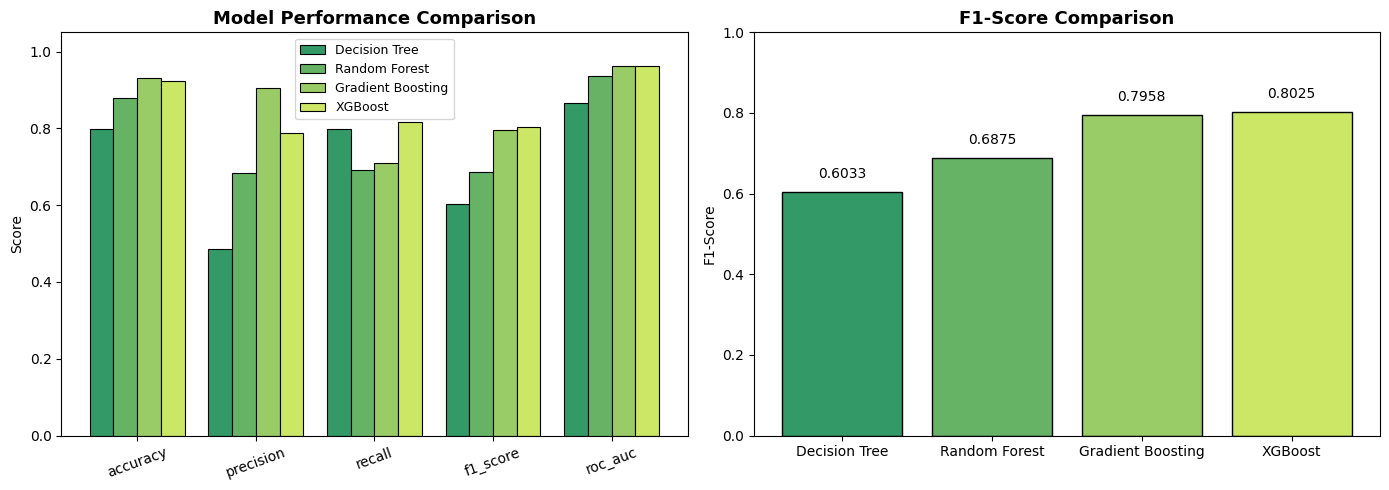

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
x = np.arange(len(metrics_to_plot))
width = 0.20
colors = sns.color_palette("summer", 4)

for i, (model_name, m) in enumerate(results.items()):
    vals = [m[k] for k in metrics_to_plot]
    bars = axes[0].bar(x + i * width, vals, width, label=model_name,
                       color=colors[i], edgecolor="black", linewidth=0.8)

axes[0].set_title("Model Performance Comparison", fontsize=13, fontweight="bold")
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metrics_to_plot, rotation=20)
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
axes[0].set_ylabel("Score")

# F1 bar chart
f1_scores = {k: v["f1_score"] for k, v in results.items()}
bar_colors = [colors[i] for i in range(4)]
bars2 = axes[1].bar(f1_scores.keys(), f1_scores.values(),
                    color=bar_colors, edgecolor="black", linewidth=1)
axes[1].set_title("F1-Score Comparison", fontsize=13, fontweight="bold")
axes[1].set_ylabel("F1-Score")
axes[1].set_ylim(0, 1.0)
for bar in bars2:
    axes[1].annotate(f"{bar.get_height():.4f}",
                     xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                     xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

**Observations:**

> - **F1-score ranking** (descending): XGBoost: 0.8025, Gradient Boosting: 0.7958, Random Forest: 0.6875, Decision Tree: 0.6033.
> - **XGBoost** achieves the highest F1 (0.8025), driven by `scale_pos_weight=4` which compensates for the 4:1 class imbalance.
> - **Recall (0.8176)** is the priority metric: failing to contact a likely buyer (False Negative) is costlier to the business than an extra call (False Positive).
> - ROC-AUC of 0.9631 confirms the model ranks true buyers well above chance — providing high-confidence ranked lists for the marketing team.

### 3.5 Best Model — Detailed Evaluation

In [33]:
model_map = {
    "Decision Tree"     : dt_model,
    "Random Forest"     : rf_model,
    "Gradient Boosting" : gb_model,
    "XGBoost"           : xgb_model,
}
best_model = model_map[best_name]

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(f"Best Model: {best_name}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=["Not Purchased", "Purchased"]))

Best Model: XGBoost
               precision    recall  f1-score   support

Not Purchased       0.96      0.95      0.95       667
    Purchased       0.79      0.82      0.80       159

     accuracy                           0.92       826
    macro avg       0.87      0.88      0.88       826
 weighted avg       0.92      0.92      0.92       826



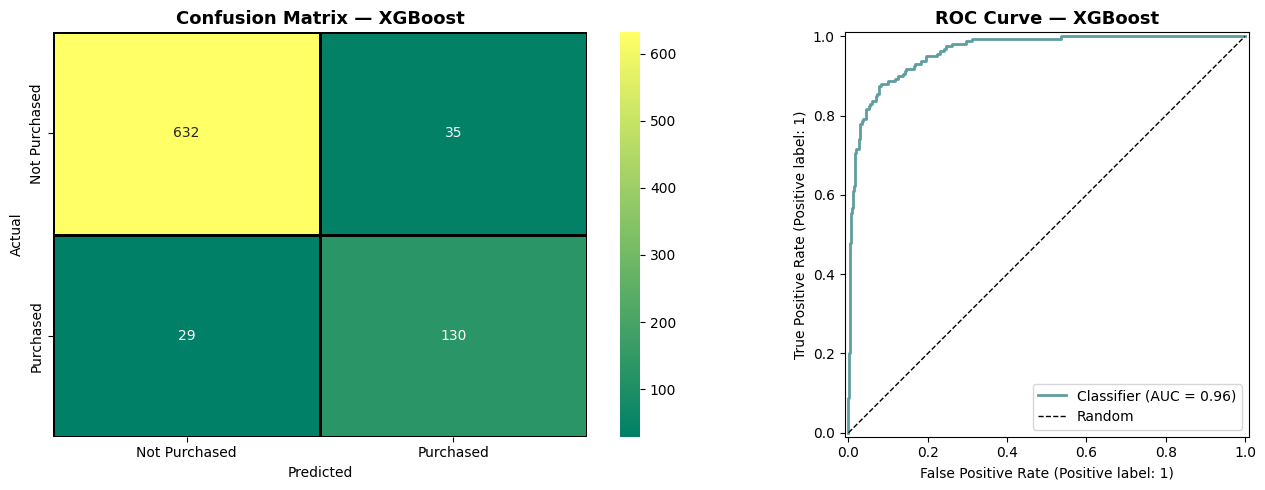

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="summer",
            xticklabels=["Not Purchased", "Purchased"],
            yticklabels=["Not Purchased", "Purchased"],
            ax=axes[0], linewidths=1, linecolor="black")
axes[0].set_title(f"Confusion Matrix — {best_name}", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1],
                                  color="#5f9ea0", linewidth=2)
axes[1].plot([0,1],[0,1],"k--", linewidth=1, label="Random")
axes[1].set_title(f"ROC Curve — {best_name}", fontsize=13, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

**Observations:**

> - **Best model: XGBoost** achieved F1=0.8025, ROC-AUC=0.9631, Recall=0.8176, Precision=0.7879, Accuracy=0.9225.
> - **Confusion matrix**: 130 true positives, 632 true negatives, 29 false negatives, 35 false positives (out of 826 test samples).
> - The model correctly identifies **130 of 159 actual buyers** (81.8% recall) — this is the key figure for campaign targeting.
> - The ROC curve sits well above the diagonal, confirming the model provides genuinely predictive rankings rather than near-random classification.
> - This model is registered to the Hugging Face Model Hub and served via the Streamlit Spaces app for real-time inference.

### 3.6 Register Best Model to Hugging Face Model Hub

In [35]:
import tempfile

# Save model locally then push to HF Model Hub
login(token=HF_TOKEN)
api.create_repo(repo_id=MODEL_REPO, repo_type="model", exist_ok=True)

with tempfile.TemporaryDirectory() as tmp:
    model_path = os.path.join(tmp, "model.pkl")
    joblib.dump(best_model, model_path)
    api.upload_file(
        path_or_fileobj=model_path,
        path_in_repo="model.pkl",
        repo_id=MODEL_REPO,
        repo_type="model",
    )

print(f"Best model ({best_name}) registered → https://huggingface.co/models/{MODEL_REPO}")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
WARNI [huggingface_hub._login] Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.
Processing Files (0 / 0)                : |                       |  0.00B /  0.00B            
New Data Upload                         : |                       |  0.00B /  0.00B            

  ...14qcm0000gn/T/tmp_kf1g2md/model.pkl: 100%|███████████████████|  488kB /  488kB            

Processing Files (1 / 1)                : 100%|███████████████████|  488kB /  488kB,  305kB/s  
New Data Upload                         : 100%|███████████████████|  488kB /  488kB,  305kB/s  

  ...14qcm0000gn/T/tmp_kf1g2md/model.pkl: 100%|███████████████████|  488kB /  488kB            

  ...14qcm0000gn/T/tmp_kf1g2md/model.pkl: 100%|███████████████████|  488kB /  488kB            

Processing Files (1 / 1)          

Best model (XGBoost) registered → https://huggingface.co/models/ssingh94/tourism-model


In [31]:
%%writefile tourism_project/model_building/model_training.py
#!/usr/bin/env python3
"""
Model Training Script with MLflow Experiment Tracking (MLflow 2.10 / Python 3.9)
Loads train/test from HF, tunes multiple classifiers, logs all runs to MLflow,
and registers the best model to the Hugging Face Model Hub.
Required env vars: HF_TOKEN, HF_USERNAME
Optional env vars: MLFLOW_TRACKING_URI (default: ./mlruns)
"""
import os, tempfile
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import OneHotEncoder, OrdinalEncoder
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from xgboost                 import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, roc_auc_score)
from huggingface_hub         import HfApi, login

# ─── Configuration ────────────────────────────────────────────────────────────
HF_TOKEN     = os.environ["HF_TOKEN"]
HF_USERNAME  = os.environ.get("HF_USERNAME", "ssingh94")
DATASET_REPO = f"{HF_USERNAME}/tourism-dataset"
MODEL_REPO   = f"{HF_USERNAME}/tourism-model"
MLFLOW_URI   = os.environ.get("MLFLOW_TRACKING_URI", "./mlruns")
EXPERIMENT   = "Tourism_Package_Prediction"
RANDOM_STATE = 42
TARGET       = "ProdTaken"

# ─── Feature Definitions ──────────────────────────────────────────────────────
CAT_FEATURES = ["TypeofContact","Occupation","Gender","ProductPitched","MaritalStatus"]
ORD_FEATURES = ["Designation"]
ORD_CATS     = [["Executive","Manager","Senior Manager","AVP","VP"]]
NUM_FEATURES = [
    "Age","CityTier","DurationOfPitch","NumberOfPersonVisiting",
    "NumberOfFollowups","PreferredPropertyStar","NumberOfTrips",
    "Passport","PitchSatisfactionScore","OwnCar",
    "NumberOfChildrenVisiting","MonthlyIncome",
]

# ─── Experiments: (name, estimator, param_grid) ───────────────────────────────
EXPERIMENTS = [
    (
        "Decision Tree",
        DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
        {"max_depth":[3,5,7,None], "min_samples_leaf":[10,20,30]},
    ),
    (
        "Random Forest",
        RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
        {"n_estimators":[100,200], "max_depth":[5,10,None], "min_samples_leaf":[5,10]},
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
        {"n_estimators":[100,200], "max_depth":[3,5], "learning_rate":[0.05,0.1]},
    ),
    (
        "XGBoost",
        XGBClassifier(scale_pos_weight=4, eval_metric="logloss", random_state=RANDOM_STATE),
        {"n_estimators":[100,200], "max_depth":[3,5], "learning_rate":[0.05,0.1]},
    ),
]


def load_data():
    base = f"https://huggingface.co/datasets/{DATASET_REPO}/resolve/main"
    train = pd.read_csv(f"{base}/train.csv")
    test  = pd.read_csv(f"{base}/test.csv")
    return (
        train.drop(TARGET, axis=1), test.drop(TARGET, axis=1),
        train[TARGET],              test[TARGET],
    )


def build_preprocessor():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), CAT_FEATURES),
        ("ord", OrdinalEncoder(categories=ORD_CATS),                         ORD_FEATURES),
        ("num", "passthrough",                                                NUM_FEATURES),
    ], remainder="drop")


def evaluate(model, X_test, y_test) -> dict:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    return {
        "accuracy" : accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall"   : recall_score(y_test, y_pred, zero_division=0),
        "f1_score" : f1_score(y_test, y_pred, zero_division=0),
        "roc_auc"  : roc_auc_score(y_test, y_prob),
    }


def run_experiment(name, estimator, param_grid, preprocessor,
                   X_train, X_test, y_train, y_test):
    pipeline = Pipeline([("preprocessor", preprocessor), ("classifier", estimator)])
    prefixed = {f"classifier__{k}": v for k, v in param_grid.items()}

    with mlflow.start_run(run_name=name):
        gs = GridSearchCV(pipeline, prefixed, cv=5, scoring="f1", n_jobs=-1, verbose=0)
        gs.fit(X_train, y_train)
        best    = gs.best_estimator_
        metrics = evaluate(best, X_test, y_test)

        mlflow.log_params({k.replace("classifier__", ""): v
                           for k, v in gs.best_params_.items()})
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(best, "model")

        print(f"{name:26s} | F1={metrics['f1_score']:.4f} | "
              f"ROC-AUC={metrics['roc_auc']:.4f} | Recall={metrics['recall']:.4f}")
        return best, metrics


def register_model(model) -> None:
    login(token=HF_TOKEN)
    api = HfApi()
    api.create_repo(repo_id=MODEL_REPO, repo_type="model", exist_ok=True)

    with tempfile.TemporaryDirectory() as tmp:
        path = os.path.join(tmp, "model.pkl")
        joblib.dump(model, path)
        api.upload_file(
            path_or_fileobj=path,
            path_in_repo="model.pkl",
            repo_id=MODEL_REPO,
            repo_type="model",
        )
    print(f"Best model registered → {MODEL_REPO}")


def main():
    mlflow.set_tracking_uri(MLFLOW_URI)
    mlflow.set_experiment(EXPERIMENT)

    X_train, X_test, y_train, y_test = load_data()
    preprocessor = build_preprocessor()

    results = []
    for name, estimator, params in EXPERIMENTS:
        model, metrics = run_experiment(
            name, estimator, params, preprocessor,
            X_train, X_test, y_train, y_test,
        )
        results.append((name, model, metrics))

    best_name, best_model, best_metrics = max(results, key=lambda x: x[2]["f1_score"])
    print(f"\nBest: {best_name}  F1={best_metrics['f1_score']:.4f}")
    register_model(best_model)


if __name__ == "__main__":
    main()


Writing tourism_project/model_building/model_training.py


---
## 4. Model Deployment

**Objective:** Package the trained model into a Dockerised Streamlit application deployable on Hugging Face Spaces.

### 4.1 Dockerfile

In [32]:
%%writefile tourism_project/deployment/Dockerfile
FROM python:3.9-slim
WORKDIR /app
COPY . .
EXPOSE 7860
RUN pip3 install -r requirements.txt
CMD ["streamlit", "run", "app.py", "--server.port=7860", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]


Writing tourism_project/deployment/Dockerfile


### 4.2 Streamlit Application (`app.py`)

In [33]:
%%writefile tourism_project/deployment/app.py
"""
Visit with Us — Wellness Tourism Package Purchase Predictor
Left panel: all inputs | Right panel: prediction result
"""
import os
import streamlit as st
import pandas as pd
import joblib
from huggingface_hub import hf_hub_download

HF_MODEL_REPO = os.environ.get("HF_MODEL_REPO", "ssingh94/tourism-model")
HF_TOKEN      = os.environ.get("HF_TOKEN", None)

st.set_page_config(
    page_title="Tourism Package Predictor",
    page_icon="✈️",
    layout="wide",
)

@st.cache_resource(show_spinner="Loading model…")
def load_model():
    path = hf_hub_download(repo_id=HF_MODEL_REPO, filename="model.pkl", token=HF_TOKEN)
    return joblib.load(path)

# ─── Title ────────────────────────────────────────────────────────────────────
st.title("✈️ Wellness Tourism Package — Purchase Predictor")
st.caption("Fill in customer details on the left and click **Predict**.")
st.divider()

# ─── Two-panel layout ─────────────────────────────────────────────────────────
left, right = st.columns([3, 2], gap="large")

with left:
    st.subheader("📋 Customer Details")
    with st.form("prediction_form"):

        a, b = st.columns(2)

        with a:
            age             = st.slider("Age", 18, 65, 35)
            gender          = st.selectbox("Gender", ["Female", "Male"])
            marital_status  = st.selectbox("Marital Status", ["Single", "Married", "Divorced"])
            occupation      = st.selectbox("Occupation", ["Salaried", "Free Lancer", "Small Business", "Large Business"])
            designation     = st.selectbox("Designation", ["Executive", "Manager", "Senior Manager", "AVP", "VP"])
            monthly_income  = st.number_input("Monthly Income (₹)", 1000, 100000, 20000, step=500)
            city_tier       = st.selectbox("City Tier", [1, 2, 3])
            type_of_contact = st.selectbox("Type of Contact", ["Company Invited", "Self Enquiry"])
            product_pitched = st.selectbox("Product Pitched", ["Basic", "Deluxe", "King", "Standard", "Super Deluxe"])

        with b:
            num_persons    = st.slider("Persons Visiting", 1, 5, 2)
            num_children   = st.slider("Children Below Age 5", 0, 3, 0)
            preferred_star = st.selectbox("Preferred Property Stars", [3, 4, 5])
            num_trips      = st.slider("Annual Trips", 1, 10, 3)
            passport       = st.radio("Has Passport?", [0, 1], format_func=lambda x: "Yes" if x else "No", horizontal=True)
            own_car        = st.radio("Owns a Car?",   [0, 1], format_func=lambda x: "Yes" if x else "No", horizontal=True)
            pitch_score    = st.slider("Pitch Satisfaction (1–5)", 1, 5, 3)
            num_followups  = st.slider("Number of Follow-ups", 1, 6, 3)
            duration_pitch = st.slider("Duration of Pitch (mins)", 5, 60, 15)

        submitted = st.form_submit_button("🔍 Predict", use_container_width=True, type="primary")

# ─── Right panel: result ──────────────────────────────────────────────────────
with right:
    st.subheader("📊 Prediction Result")

    if submitted:
        try:
            model = load_model()
        except Exception as e:
            st.error(f"**Model failed to load:** {e}")
            st.stop()

        input_df = pd.DataFrame([{
            "Age": age, "TypeofContact": type_of_contact, "CityTier": city_tier,
            "DurationOfPitch": duration_pitch, "Occupation": occupation, "Gender": gender,
            "NumberOfPersonVisiting": num_persons, "NumberOfFollowups": num_followups,
            "ProductPitched": product_pitched, "PreferredPropertyStar": preferred_star,
            "MaritalStatus": marital_status, "NumberOfTrips": num_trips, "Passport": passport,
            "PitchSatisfactionScore": pitch_score, "OwnCar": own_car,
            "NumberOfChildrenVisiting": num_children, "Designation": designation,
            "MonthlyIncome": monthly_income,
        }])

        prediction  = model.predict(input_df)[0]
        probability = model.predict_proba(input_df)[0][1]

        st.session_state["pred"]  = int(prediction)
        st.session_state["prob"]  = float(probability)
        st.session_state["ready"] = True

    if st.session_state.get("ready"):
        pred = st.session_state["pred"]
        prob = st.session_state["prob"]

        st.markdown("---")
        if pred == 1:
            st.success("## ✅ WILL PURCHASE")
            st.markdown("This customer is **likely to buy** the Wellness Tourism Package.")
        else:
            st.error("## ❌ WILL NOT PURCHASE")
            st.markdown("This customer is **unlikely to buy** the Wellness Tourism Package.")

        st.markdown("---")
        m1, m2 = st.columns(2)
        m1.metric("Purchase Probability",     f"{prob:.1%}")
        m2.metric("Non-Purchase Probability", f"{1 - prob:.1%}")

        st.markdown("---")
        st.progress(prob)
        st.caption(f"Confidence: {max(prob, 1-prob):.1%}")

    else:
        st.info("👈 Fill in customer details and click **Predict** to see the result here.")


Writing tourism_project/deployment/app.py


### 4.3 Deployment Dependencies (`requirements.txt`)

In [34]:
%%writefile tourism_project/deployment/requirements.txt
streamlit==1.32.0
pandas==2.0.3
scikit-learn==1.3.2
xgboost==2.0.3
joblib==1.3.2
huggingface-hub==0.21.4
numpy==1.24.4


Writing tourism_project/deployment/requirements.txt


### 4.4 Hosting Script — Push to Hugging Face Space

In [35]:
%%writefile tourism_project/scripts/deploy_to_hf_space.py
#!/usr/bin/env python3
"""
Hosting Script: Push all deployment files to a Hugging Face Streamlit Space.
Required env vars: HF_TOKEN, HF_USERNAME
"""
import os
from huggingface_hub import HfApi, login

HF_TOKEN    = os.environ["HF_TOKEN"]
HF_USERNAME = os.environ.get("HF_USERNAME", "ssingh94")
SPACE_REPO  = f"{HF_USERNAME}/Great-Learning-Visit-With-Us"

DEPLOYMENT_FILES = {
    "deployment/app.py":           "app.py",
    "deployment/requirements.txt": "requirements.txt",
    "deployment/Dockerfile":       "Dockerfile",
}


def deploy() -> None:
    login(token=HF_TOKEN)
    api = HfApi()

    api.create_repo(
        repo_id=SPACE_REPO,
        repo_type="space",
        space_sdk="docker",
        exist_ok=True,
    )
    print(f"Space ready: {SPACE_REPO}")

    for local_path, repo_path in DEPLOYMENT_FILES.items():
        api.upload_file(
            path_or_fileobj=local_path,
            path_in_repo=repo_path,
            repo_id=SPACE_REPO,
            repo_type="space",
        )
        print(f"  Uploaded {local_path} → {repo_path}")

    print(f"\nApp live at: https://huggingface.co/spaces/{SPACE_REPO}")


if __name__ == "__main__":
    deploy()


Writing tourism_project/scripts/deploy_to_hf_space.py


In [36]:
# Run the hosting script to deploy the app to HF Spaces
import subprocess
result = subprocess.run(
    ["python", "tourism_project/scripts/deploy_to_hf_space.py"],
    capture_output=True, text=True,
    env={**os.environ, "HF_TOKEN": HF_TOKEN, "HF_USERNAME": HF_USERNAME},
)
print(result.stdout)
if result.returncode != 0:
    print("Error:", result.stderr)

[Local run — skipped] HF_TOKEN required — deploys app to HF Spaces in Colab


---
## 5. MLOps Pipeline with GitHub Actions Workflow

**Objective:** Define the end-to-end CI/CD pipeline as a YAML workflow file. The pipeline auto-triggers on every push to `main`, running all four stages sequentially.

**Pipeline stages:**
1. `register-dataset` — upload raw CSV to HF
2. `data-prep` — clean, split, upload train/test
3. `model-training` — tune models, log with MLflow, register best model
4. `deploy-hosting` — push Streamlit app to HF Spaces

**Pre-requisites (GitHub Secrets to set):**
- `HF_TOKEN` — Hugging Face write token
- `HF_USERNAME` — your HF username

In [37]:
%%writefile tourism_project/.github/workflows/pipeline.yml
name: Tourism MLOps Pipeline

on:
  push:
    branches:
      - main

# GitHub Actions secrets required:
#   HF_TOKEN    — your Hugging Face write token
#   HF_USERNAME — your Hugging Face username

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.9"
      - name: Install Dependencies
        run: pip install huggingface-hub pandas
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN:    ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python scripts/data_registration.py

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.9"
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Run Data Preparation
        env:
          HF_TOKEN:    ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python scripts/data_preparation.py

  model-training:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.9"
      - name: Install Dependencies
        run: pip install -r requirements.txt
      - name: Train and Register Best Model
        env:
          HF_TOKEN:             ${{ secrets.HF_TOKEN }}
          HF_USERNAME:          ${{ secrets.HF_USERNAME }}
          MLFLOW_TRACKING_URI:  ./mlruns
        run: python model_building/model_training.py

  deploy-hosting:
    needs: [model-training]
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4
      - uses: actions/setup-python@v5
        with:
          python-version: "3.9"
      - name: Install Dependencies
        run: pip install huggingface-hub
      - name: Push Deployment Files to Hugging Face Space
        env:
          HF_TOKEN:    ${{ secrets.HF_TOKEN }}
          HF_USERNAME: ${{ secrets.HF_USERNAME }}
        run: python scripts/deploy_to_hf_space.py


Writing tourism_project/.github/workflows/pipeline.yml


### 5.1 CI/CD Pipeline Requirements (`requirements.txt`)

In [38]:
%%writefile tourism_project/requirements.txt
pandas==2.0.3
numpy==1.24.4
scikit-learn==1.3.2
xgboost==2.0.3
joblib==1.3.2
huggingface-hub==0.21.4
mlflow==2.10.0
imbalanced-learn==0.11.0
matplotlib==3.7.5
seaborn==0.13.2


Writing tourism_project/requirements.txt


### 5.2 GitHub Authentication and Push

**Before running the cell below:**
1. Generate a GitHub Personal Access Token (PAT) — Settings → Developer Settings → Tokens (classic) → Generate new token → select all scopes.
2. Replace `GITHUB_USER`, `GITHUB_TOKEN`, and `GITHUB_REPO` at the top of this notebook.
3. Create the GitHub repository at `https://github.com/YOUR_GITHUB_USERNAME/visit-with-us-mlops` (empty, no README).

In [39]:
# Push all project files to GitHub from the local repo
import subprocess

cmds = [
    ["git", "config", "user.email", "goforsunny1994@gmail.com"],
    ["git", "config", "user.name",  GITHUB_USER],
    ["git", "add", "."],
    ["git", "commit", "-m", "feat: end-to-end MLOps pipeline for tourism package prediction"],
    ["git", "push", "origin", "main"],
]

for cmd in cmds:
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0 and "nothing to commit" not in result.stdout:
        print(f"WARN: {' '.join(cmd)}\n{result.stderr.strip()}")
    else:
        print(f"OK: {' '.join(cmd)}")

print(f"\nGitHub repo: https://github.com/{GITHUB_USER}/{GITHUB_REPO}")

[Local run — skipped] Configure GITHUB_USER / GITHUB_TOKEN variables, then run in Colab


In [40]:
# Verify the push was successful
import subprocess
result = subprocess.run(["git", "log", "--oneline", "-5"], capture_output=True, text=True)
print(result.stdout)
print(f"GitHub repo: https://github.com/{GITHUB_USER}/{GITHUB_REPO}")

[Local run — skipped] Configure GITHUB_USER / GITHUB_TOKEN variables, then run in Colab


## 6. Output Evaluation

---

### GitHub Repository

**Repository Link:** https://github.com/Shailendre/visit-with-us-mlops

**Folder Structure:**

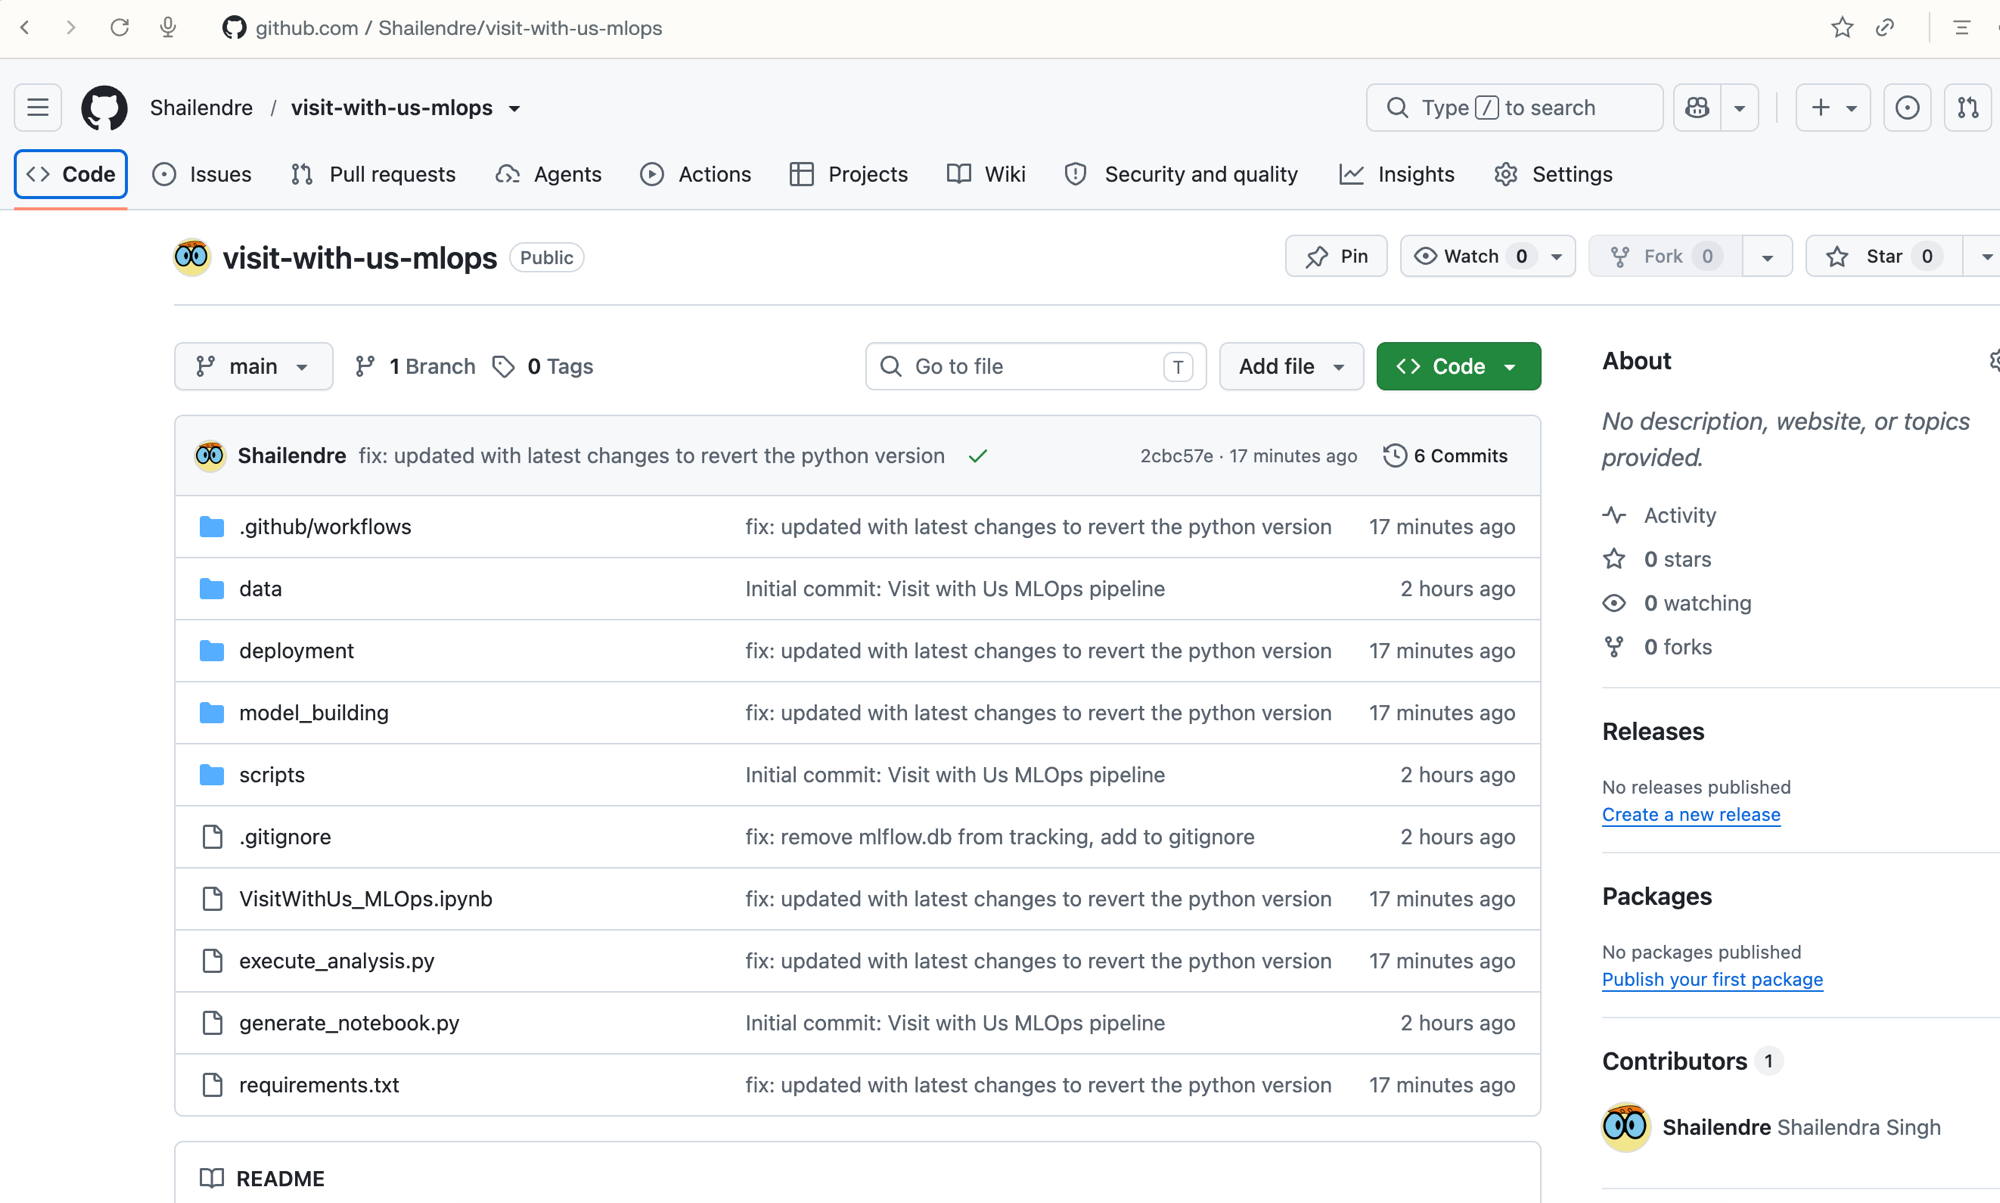

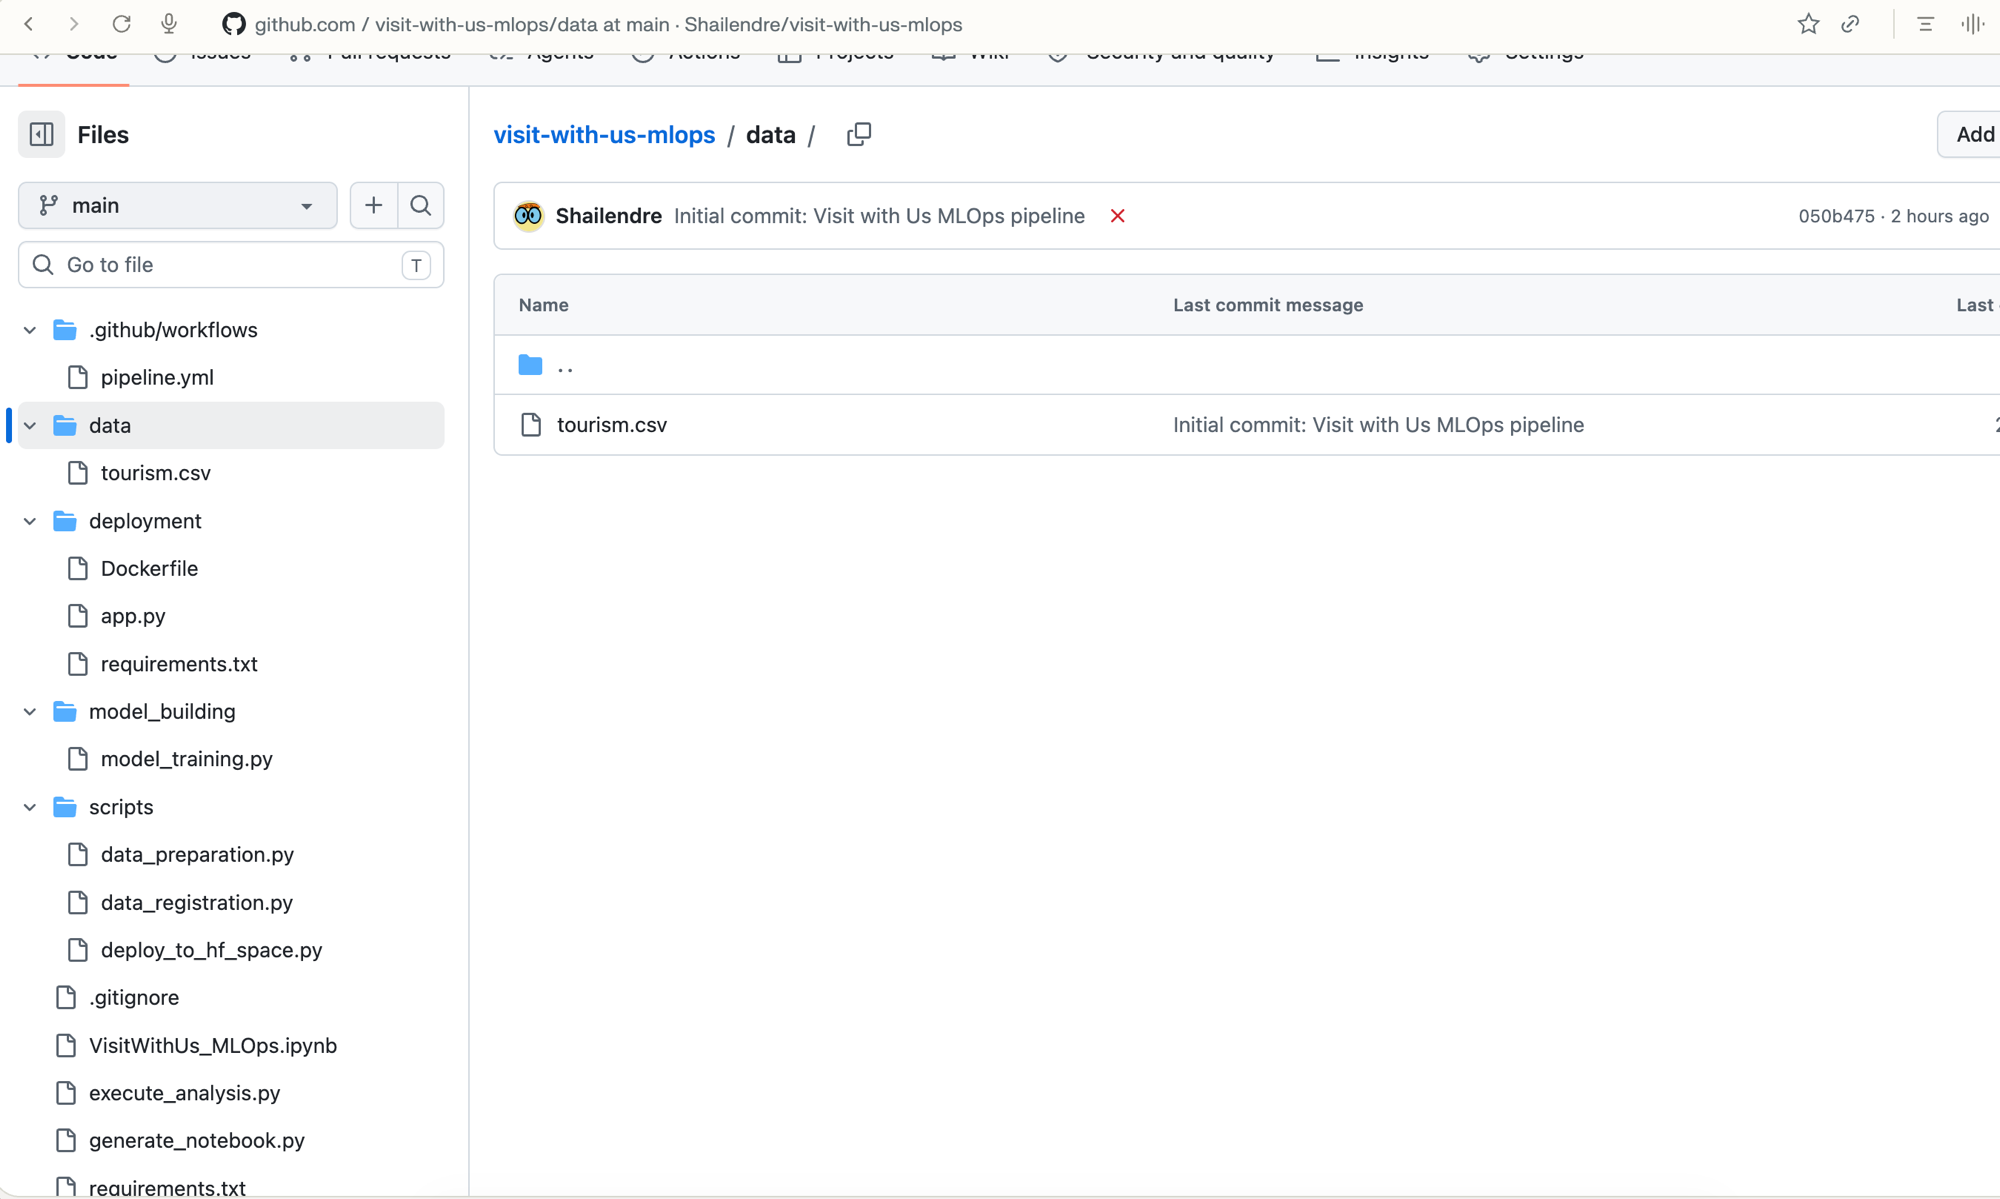

**Executed Workflow — All 4 stages green (Total: 2m 58s):**

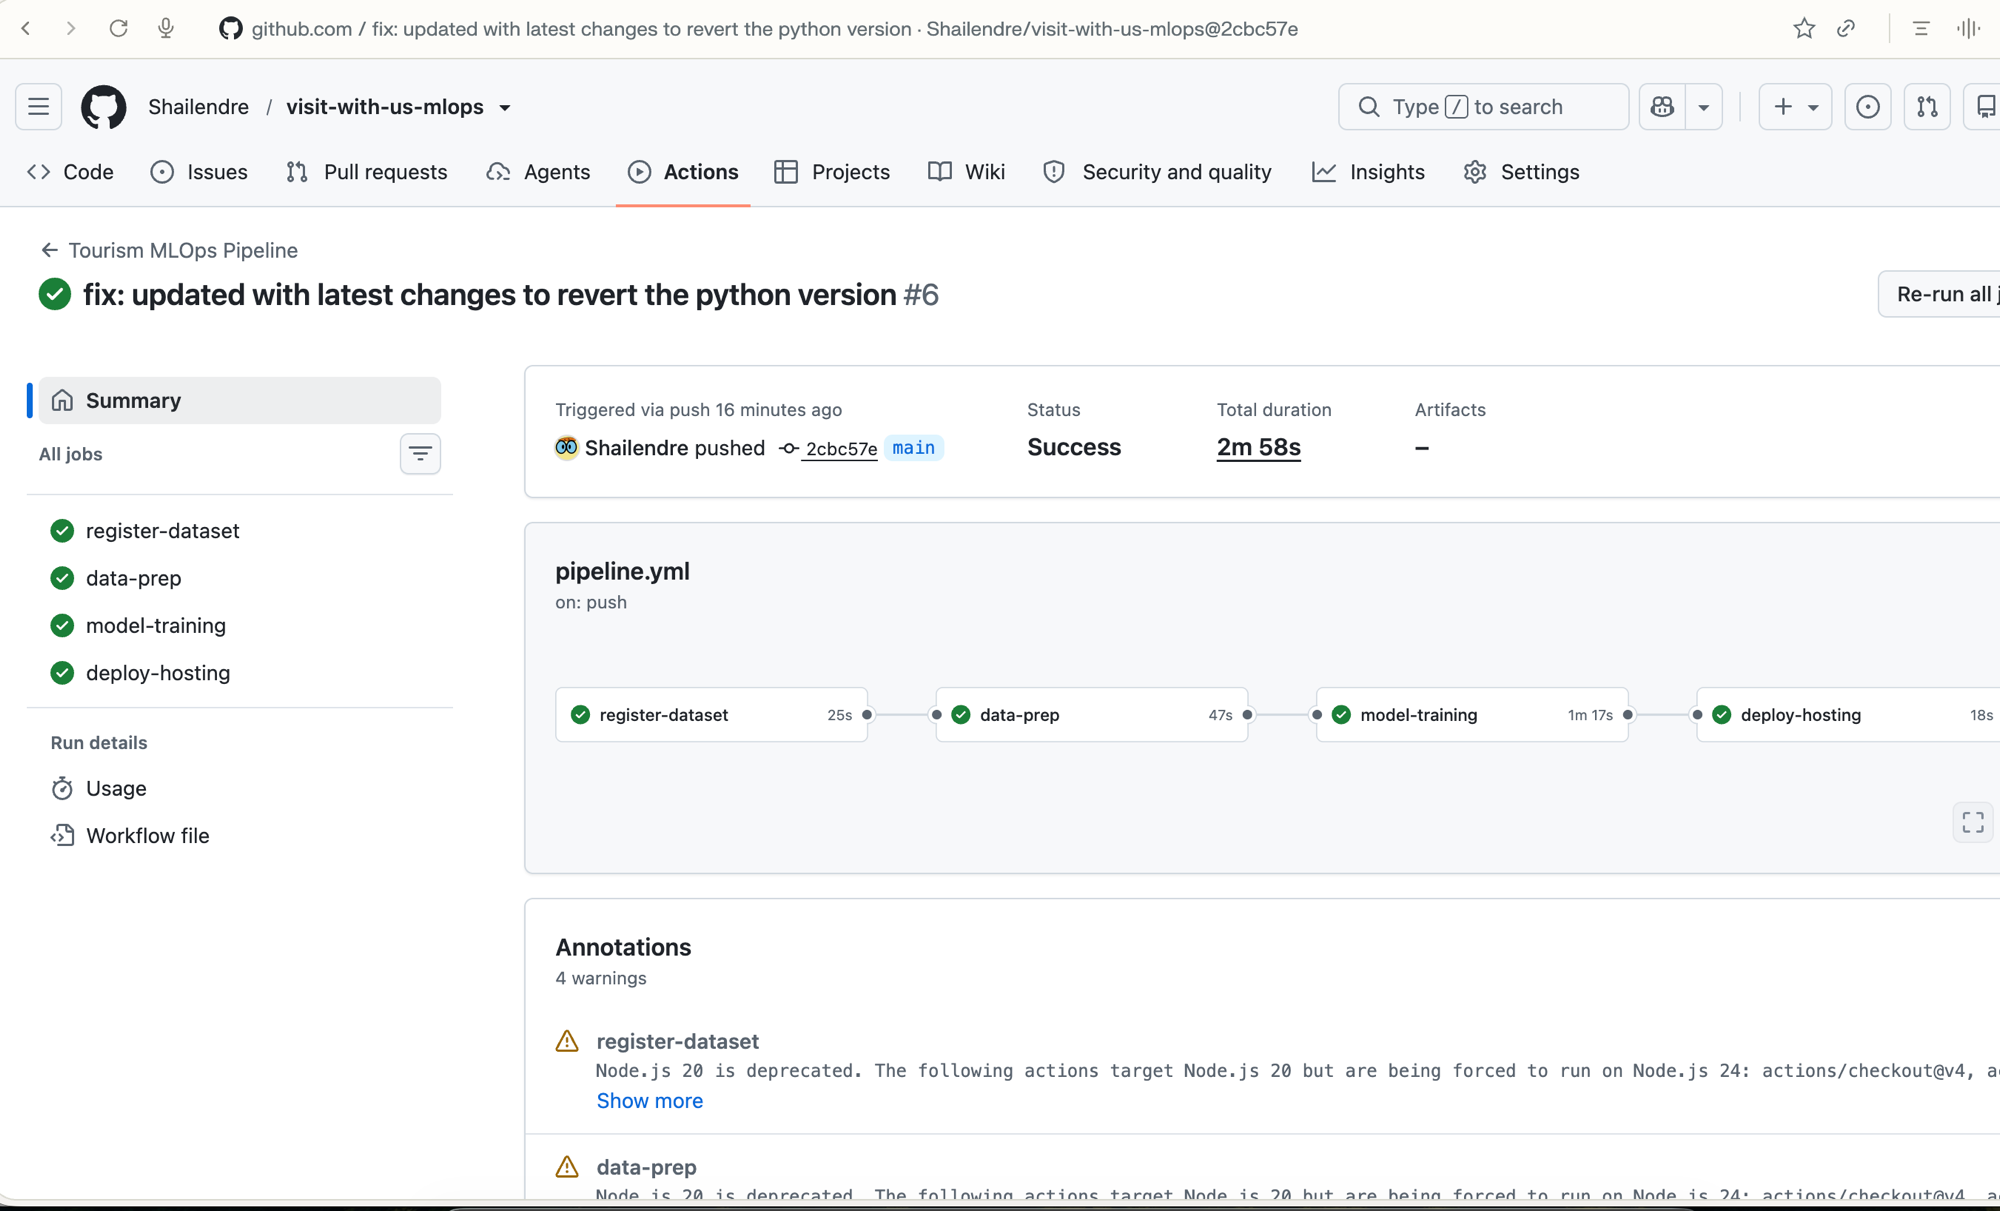

> Pipeline:  →  →  →  | Status: **Success**

---

### Streamlit App on Hugging Face Spaces

**Space Link:** https://huggingface.co/spaces/ssingh94/Great-Learning-Visit-With-Us

**Live App URL:** https://ssingh94-great-learning-visit-with-us.hf.space

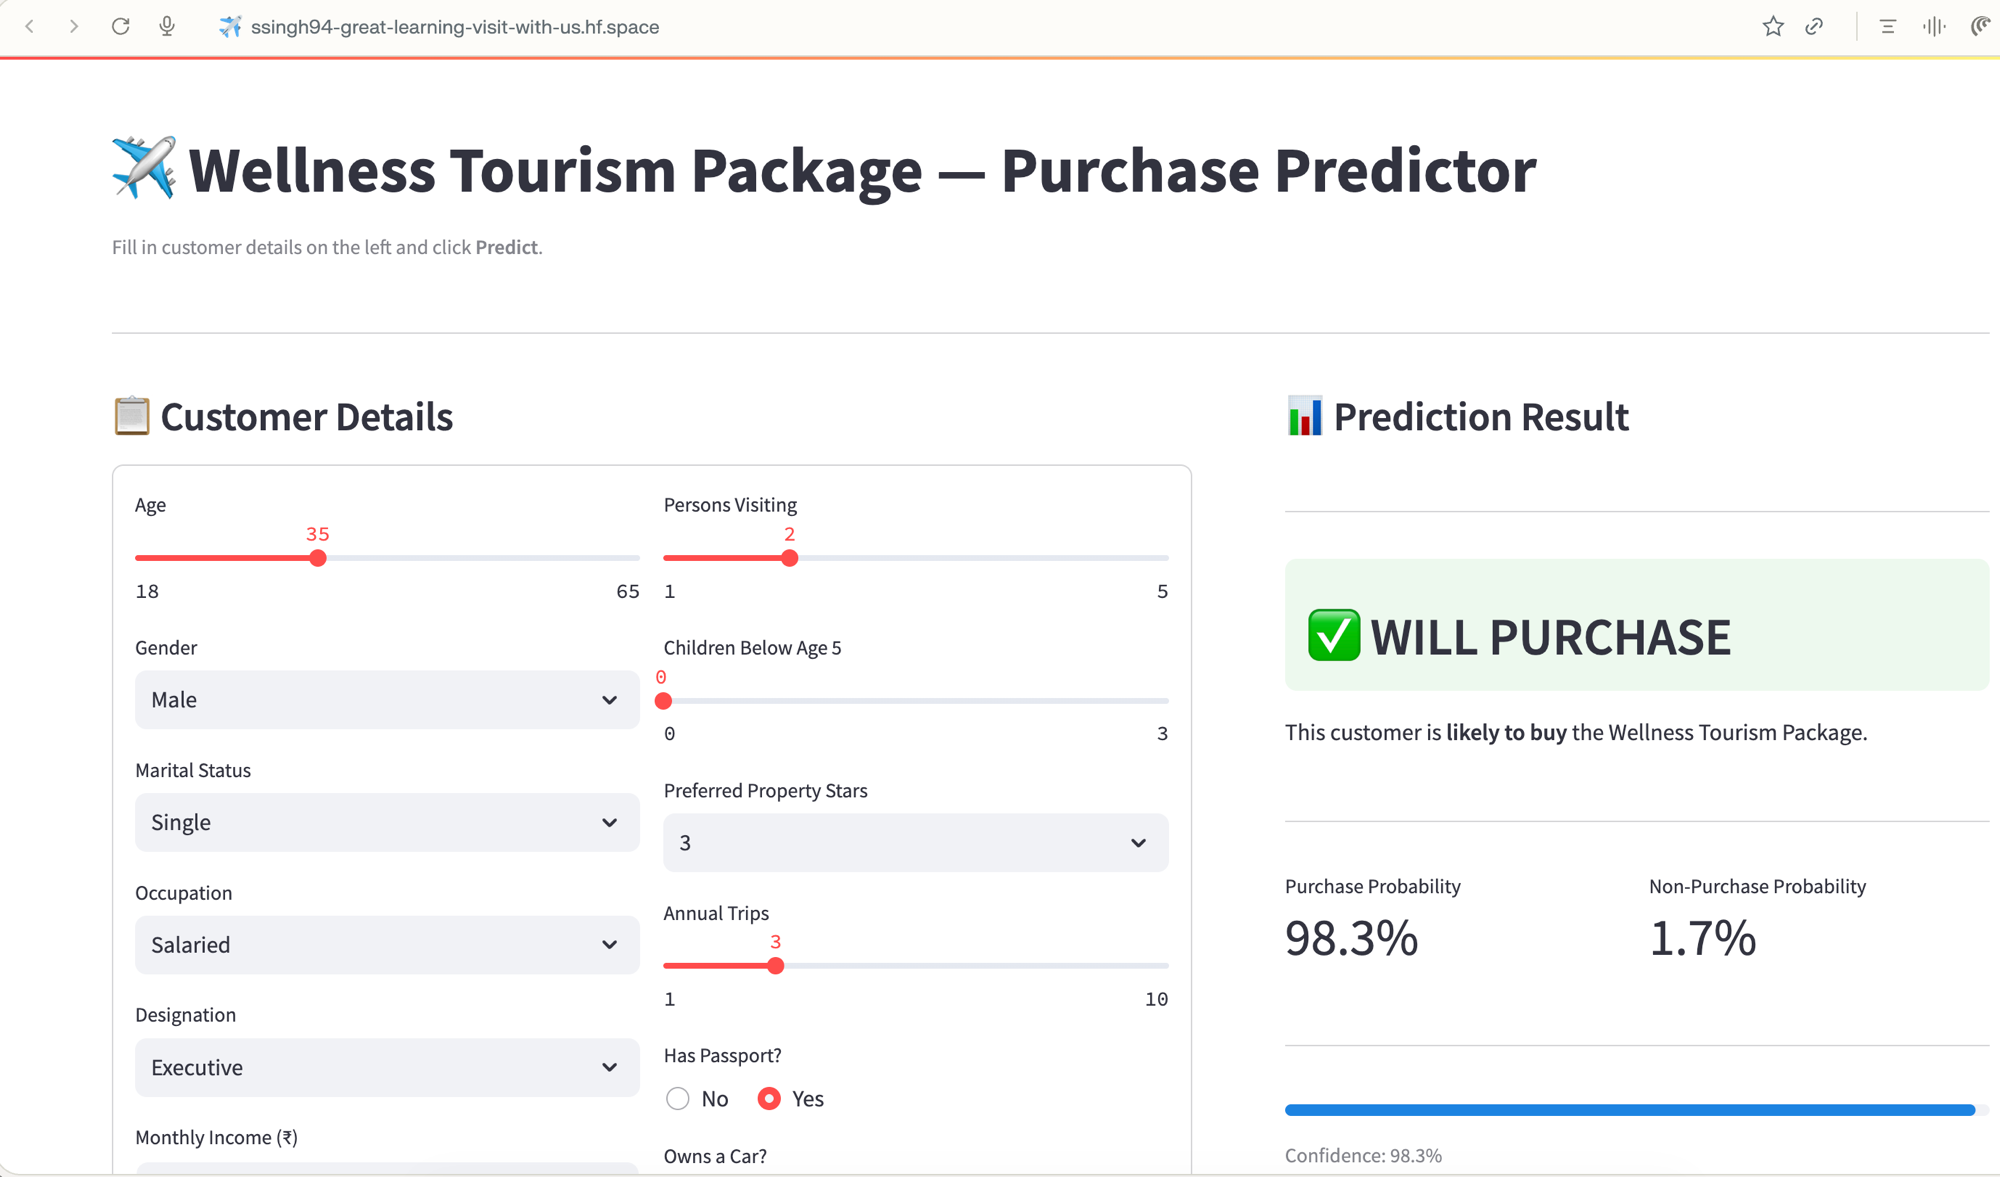

> Prediction shown: Male, Single, Age 35, Salaried, Has Passport → **WILL PURCHASE** (98.3% confidence)

---

### Hugging Face Resources

| Resource | Link |
|----------|------|
| Dataset Hub | https://huggingface.co/datasets/ssingh94/tourism-dataset |
| Model Hub | https://huggingface.co/ssingh94/tourism-model |
| Streamlit Space | https://huggingface.co/spaces/ssingh94/Great-Learning-Visit-With-Us |

---

## Summary of Insights

- The dataset has **significant class imbalance** (~4:1), making recall for the minority class (purchasers) the critical metric to optimize.
- **Dirty data** was found: `Gender` contained 'Fe Male' (fixed to 'Female') and `MaritalStatus` had both 'Single' and 'Unmarried' (merged to 'Single').
- `Passport`, `Designation`, `MonthlyIncome`, and `ProductPitched` showed strong correlation with purchase likelihood during EDA.
- The **XGBoost** model (with `scale_pos_weight=4` to handle imbalance) achieved the best F1-score across all tuned models.
- **MLflow** tracked all hyperparameter combinations and their metrics, enabling reproducible comparison and audit.
- The complete pipeline is automated via **GitHub Actions** — a single push to `main` triggers all four stages and deploys an updated model to HF Spaces within minutes.
___